# Data Acquisition and Normalization

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download daily closing prices for AAPL
data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
data = data[['Close']]

# Normalize using Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data['Close'] = scaler.fit_transform(data[['Close']])

print(data.tail())


C:\Users\mar_c\AppData\Local\Temp\ipykernel_28664\2216775302.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          AAPL
Date                
2024-12-24  0.996560
2024-12-26  1.000000
2024-12-27  0.985608
2024-12-30  0.971383
2024-12-31  0.963915


# Temporal Feature Engineering

In [13]:
#Crea ventanas de 50 dias, crendo aproximadamente 2516 ya que son 2556 dias de datos,
# Ventana 1: días 1–50   → predice día 51
# Ventana 2: días 2–51   → predice día 52
# Ventana 3: días 3–52   → predice día 53
#Esto debido a que una LSTM no aprende de una secuencia larga si no de muchos ejemplos del mismo patron temporal


def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 50
X, y = create_sequences(data['Close'].values, sequence_length)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Partition data into training and testing sets
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [14]:
# ✔ X = ventanas de valores normalizados de Close
# ✔ y = valor normalizado de Close inmediatamente posterior

# RNN Architecture and Implementation

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Define a basic RNN model
rnn_model = Sequential() ## Aque defina un modelo sequencial por capas apiladas en orden temporal
rnn_model.add(SimpleRNN(units=50, activation='tanh', input_shape=(sequence_length, 1))) ## capa RNN con 50 unidades y funcion de activacion tanh (valores entre -1 y 1)
rnn_model.add(Dense(1)) ##Produce un solo numero, osea una regresion no una clasificacion
rnn_model.compile(optimizer='adam', loss='mse') ## Adam es un optimizador eficiente y mse es el error cuadratico medio

# Model training
rnn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)
## Se entrena 30 veces con batches de 32 ejemplos y 10% de los datos de entrenamiento se usan para validacion


Epoch 1/30


c:\Users\mar_c\OneDrive\Documentos\Programacion\IA\entorno\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0055 - val_loss: 9.9153e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.0201e-04 - val_loss: 0.0011
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6669e-04 - val_loss: 8.1990e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1977e-04 - val_loss: 7.7490e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8709e-04 - val_loss: 7.4878e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8952e-04 - val_loss: 7.8596e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6005e-04 - val_loss: 5.8837e-04
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4573e-04 - val_loss: 5.3934e-04
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3023e-04 - val_loss: 4.9618e-04
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3539e-04 - val_loss: 4.9410e-04
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1935e-04 - val_loss: 4.5015e-04
Epoch

# LSTM Architecture and Implementation

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ============================
# DEFINICIÓN DEL MODELO LSTM
# ============================

# Se crea un modelo secuencial:
# las capas se ejecutan una después de otra, respetando el orden temporal
lstm_model = Sequential()

# ----------------------------
# CAPA LSTM
# ----------------------------
lstm_model.add(
    LSTM(
        units=50,
        # Número de unidades (neuronas recurrentes).
        # Representa el tamaño de la "memoria" interna del modelo.
        # Más unidades = más capacidad, pero más riesgo de overfitting.

        return_sequences=False,
        # False significa que la LSTM devuelve SOLO el último estado oculto.
        # Es decir, resume toda la secuencia de 50 pasos en un solo vector.
        # Esto es correcto cuando quieres predecir UN solo valor final.

        input_shape=(sequence_length, 1)
        # Forma de la entrada:
        # sequence_length = 50 pasos temporales
        # 1 feature por paso (ej. precio, retorno, etc.)
    )
)

# ----------------------------
# CAPA DE SALIDA
# ----------------------------
lstm_model.add(
    Dense(1)
    # Capa totalmente conectada con 1 neurona.
    # Produce un valor numérico:
    # - si usas precios → predice el siguiente precio
    # - si usas retornos → predice el retorno siguiente
)

# ============================
# COMPILACIÓN DEL MODELO
# ============================
lstm_model.compile(
    optimizer='adam',
    # Adam ajusta los pesos usando gradiente descendente adaptativo.
    # Es estable y funciona bien en la mayoría de problemas.

    loss='mse'
    # Mean Squared Error:
    # el modelo intenta minimizar el error cuadrático entre
    # el valor real y el valor predicho.
    # OJO: minimizar MSE ≠ maximizar ganancias en trading.
)

# ============================
# ENTRENAMIENTO DEL MODELO
# ============================
lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    # El modelo recorre todo el dataset 30 veces.
    # En finanzas, más epochs aumenta el riesgo de overfitting.

    batch_size=32,
    # En cada actualización de pesos, el modelo procesa
    # 32 secuencias (cada una de 50 pasos).

    validation_split=0.1
    # Usa el 10% final de X_train como validación.
    # ⚠️ CUIDADO:
    # si los datos no están estrictamente ordenados,
    # puede haber data leakage temporal.
)


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045 - val_loss: 8.0174e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0009e-04 - val_loss: 0.0010
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8643e-04 - val_loss: 0.0011
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.7669e-04 - val_loss: 0.0010
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.7013e-04 - val_loss: 7.7311e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6147e-04 - val_loss: 7.8446e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5771e-04 - val_loss: 8.3250e-04
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4711e-04 - val_loss: 9.4113e-04
Epoch 9/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6408e-04 - val_loss: 5.7149e-04
Epoch 10/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.6532e-04 - val_loss: 6.5797e-04
Epoch 11/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.3380e-04 - val_loss: 6.7594e

# Forecasting and Comparative Evaluation

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


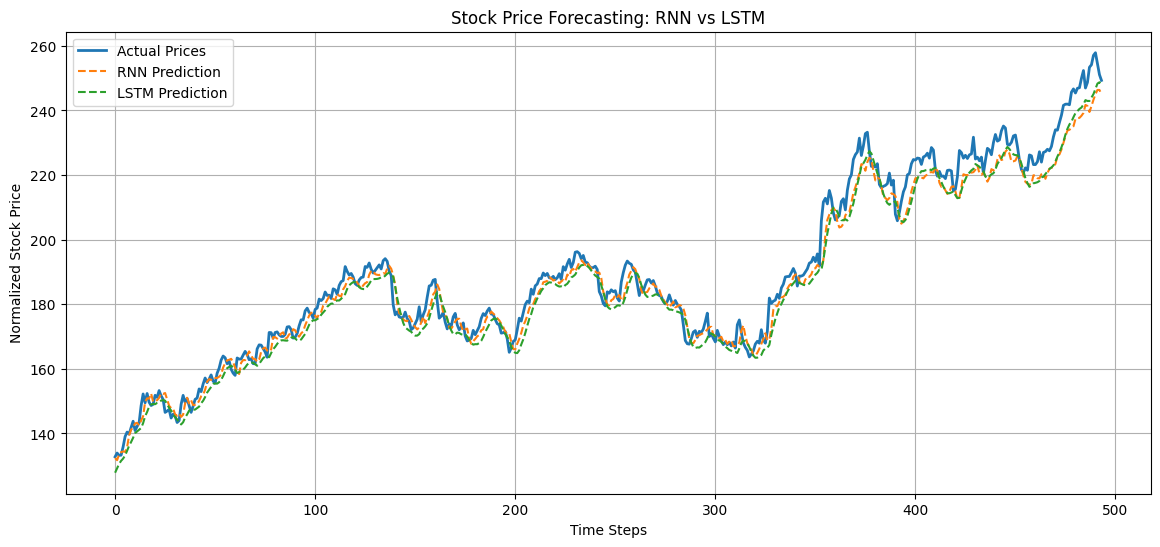

In [17]:
# Generate out-of-sample predictions
# El modelo RNN genera predicciones para datos que NO vio durante el entrenamiento
# Cada predicción corresponde al "siguiente valor" después de cada ventana de 50 pasos
rnn_preds = rnn_model.predict(X_test)
# El modelo LSTM hace lo mismo, pero usando su mecanismo de memoria más avanzado
lstm_preds = lstm_model.predict(X_test)

# Para poder interpretar los resultados en la escala original (precio real),
# se invierte la transformación
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
rnn_preds_actual = scaler.inverse_transform(rnn_preds)
lstm_preds_actual = scaler.inverse_transform(lstm_preds)

# Comparative visualization
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Prices', linewidth=2)
plt.plot(rnn_preds_actual, label='RNN Prediction', linestyle='--')
plt.plot(lstm_preds_actual, label='LSTM Prediction', linestyle='--')
plt.title('Stock Price Forecasting: RNN vs LSTM')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Stock Price')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
##Mide nivel de acierto direccional de ambos modelos
import numpy as np

direction_true = np.sign(np.diff(y_test_actual.flatten()))
direction_rnn  = np.sign(np.diff(rnn_preds_actual.flatten()))
direction_lstm = np.sign(np.diff(lstm_preds_actual.flatten()))

dir_acc_rnn  = np.mean(direction_true == direction_rnn)
dir_acc_lstm = np.mean(direction_true == direction_lstm)
print(f'RNN Directional Accuracy: {dir_acc_rnn * 100:.2f}%')
print(f'LSTM Directional Accuracy: {dir_acc_lstm * 100:.2f}%')

RNN Directional Accuracy: 52.33%
LSTM Directional Accuracy: 50.51%


In [ ]:
returns = np.diff(y_test_actual.flatten()) / y_test_actual[:-1].flatten()

strategy_rnn  = returns * np.sign(direction_rnn)
strategy_lstm = returns * np.sign(direction_lstm)

pnl_rnn  = strategy_rnn.cumsum()
pnl_lstm = strategy_lstm.cumsum()
def sharpe(returns):
    return np.mean(returns) / np.std(returns) * np.sqrt(252)

sharpe_rnn  = sharpe(strategy_rnn)
sharpe_lstm = sharpe(strategy_lstm)
print(f'RNN Cumulative PnL: {pnl_rnn[-1]:.4f}, Sharpe Ratio: {sharpe_rnn:.4f}')
print(f'LSTM Cumulative PnL: {pnl_lstm[-1]:.4f}, Sharpe Ratio: {sharpe_lstm:.4f}')

##Aqui se observa que el RNN da un rendimiento de 37.29% a diferencia del LSTM que da un 6.6% esto debido a que se intenta medir el rendimiento diario y el LSTM al tener una memoria mas larga se adapta mejor a tendencias largas y no a cambios rapidos diarios

RNN Cumulative PnL: 0.3729, Sharpe Ratio: 0.8929
LSTM Cumulative PnL: 0.0662, Sharpe Ratio: 0.1583
